<a href="https://colab.research.google.com/github/Garxxss/ml-uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B5%D0%B2%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%BC_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


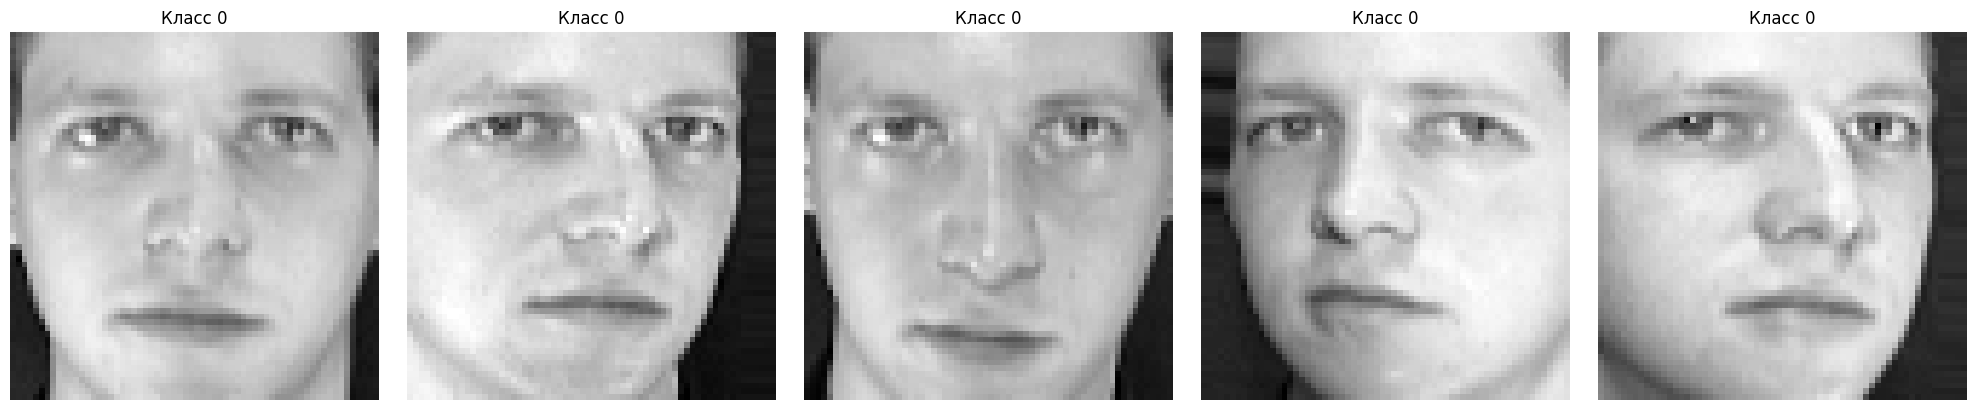

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

CatBoost пропущен: No module named 'catboost'

GradientBoosting: accuracy=0.5800, time=1103.35 sec
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       0.25      0.33      0.29         3
           4       0.00      0.00      0.00         2
           5       1.00      1.00      1.00         3
           6       1.00      0.50      0.67         2
           7       0.50      0.33      0.40         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.67      0.67      0.67         3
          11       1.00      0.67      0.80         3
          12       0.04      0.50      0.08         2
          13       0.00      0.00      0.00         2
          14       0.75      1.00      0.86         3
          15       1.00      0.50   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,train_time_sec
2,LightGBM,0.81,62.091488
1,XGBoost,0.77,68.432998
0,GradientBoosting,0.58,1103.350219


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


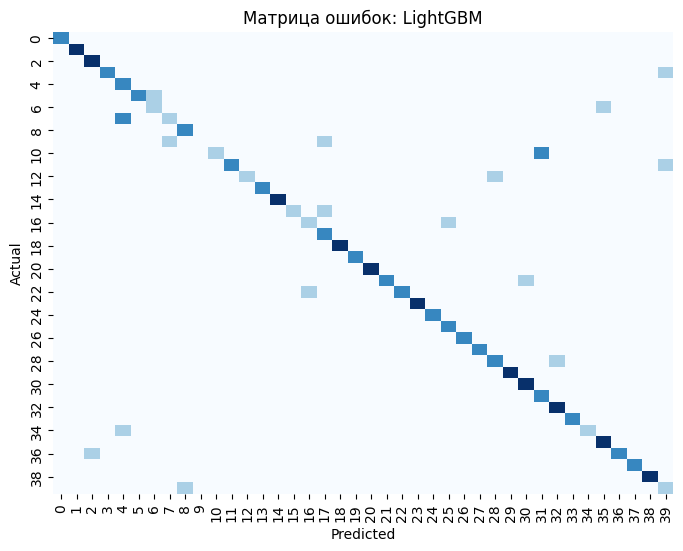

In [ ]:
import time
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

X = images.reshape(len(images), -1)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

def optional_imports_for_boosting():
    models = {"GradientBoosting": GradientBoostingClassifier(random_state=42)}
    try:
        from xgboost import XGBClassifier
        models["XGBoost"] = XGBClassifier(
            n_estimators=80,
            max_depth=3,
            learning_rate=0.08,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
        )
    except Exception as error:
        print("XGBoost пропущен:", error)
    try:
        from lightgbm import LGBMClassifier
        models["LightGBM"] = LGBMClassifier(n_estimators=80, random_state=42, verbose=-1)
    except Exception as error:
        print("LightGBM пропущен:", error)
    try:
        from catboost import CatBoostClassifier
        models["CatBoost"] = CatBoostClassifier(iterations=80, depth=4, verbose=False, random_state=42)
    except Exception as error:
        print("CatBoost пропущен:", error)
    return models

boosting_models = optional_imports_for_boosting()
boosting_results = []

for name, model in boosting_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    boosting_results.append({"model": name, "accuracy": accuracy, "train_time_sec": train_time})
    print(f"\n{name}: accuracy={accuracy:.4f}, time={train_time:.2f} sec")
    print(classification_report(y_test, y_pred, zero_division=0))

boosting_results_df = pd.DataFrame(boosting_results).sort_values("accuracy", ascending=False)
display(boosting_results_df)

best_name = boosting_results_df.iloc[0]["model"]
best_model = boosting_models[best_name]
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title(f"Матрица ошибок: {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

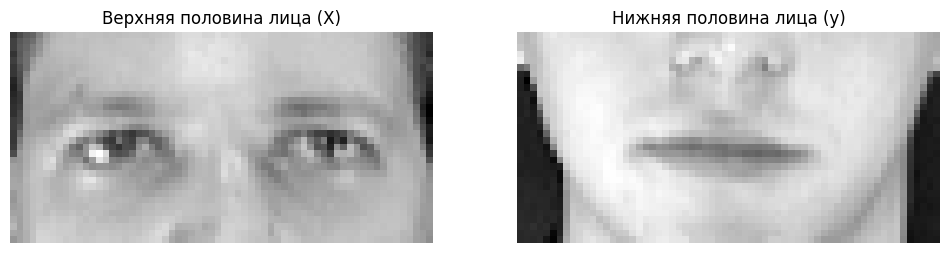

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

,model,r2_pca,mse_pixels,train_time_sec
1,XGBoostRegressor,0.27392,0.009839,89.152302
0,GradientBoostingRegressor,0.23784,0.010603,144.890802


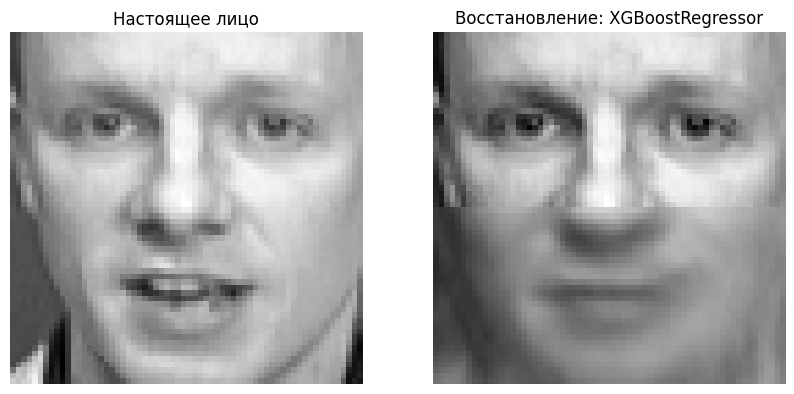

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Чтобы задача была быстрее, предсказываю не 2048 пикселей напрямую, а PCA-компоненты нижней половины лица.
n_components = 40
pca_y = PCA(n_components=n_components, random_state=42)
y_train_pca = pca_y.fit_transform(y_train)
y_test_pca = pca_y.transform(y_test)

regressors = {
    "GradientBoostingRegressor": MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=60, max_depth=2, random_state=42),
        n_jobs=-1,
    )
}

try:
    from xgboost import XGBRegressor
    regressors["XGBoostRegressor"] = XGBRegressor(
        n_estimators=80, max_depth=3, learning_rate=0.08, random_state=42, n_jobs=-1
    )
except Exception as error:
    print("XGBoostRegressor пропущен:", error)

regression_results = []
predicted_faces = {}

for name, model in regressors.items():
    start = time.time()
    model.fit(X_train, y_train_pca)
    train_time = time.time() - start
    pred_pca = model.predict(X_test)
    pred_lower = pca_y.inverse_transform(pred_pca)
    predicted_faces[name] = pred_lower
    regression_results.append({
        "model": name,
        "r2_pca": r2_score(y_test_pca, pred_pca),
        "mse_pixels": mean_squared_error(y_test, pred_lower),
        "train_time_sec": train_time,
    })

regression_results_df = pd.DataFrame(regression_results).sort_values("mse_pixels")
display(regression_results_df)

best_reg_name = regression_results_df.iloc[0]["model"]
idx = 0
predicted_lower = predicted_faces[best_reg_name][idx].reshape(32, 64)
true_lower = y_test[idx].reshape(32, 64)
upper = X_test[idx].reshape(32, 64)
reconstructed = np.vstack([upper, predicted_lower])
true_face = np.vstack([upper, true_lower])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(true_face, cmap="gray")
axes[0].set_title("Настоящее лицо")
axes[0].axis("off")
axes[1].imshow(reconstructed, cmap="gray")
axes[1].set_title(f"Восстановление: {best_reg_name}")
axes[1].axis("off")
plt.show()


## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

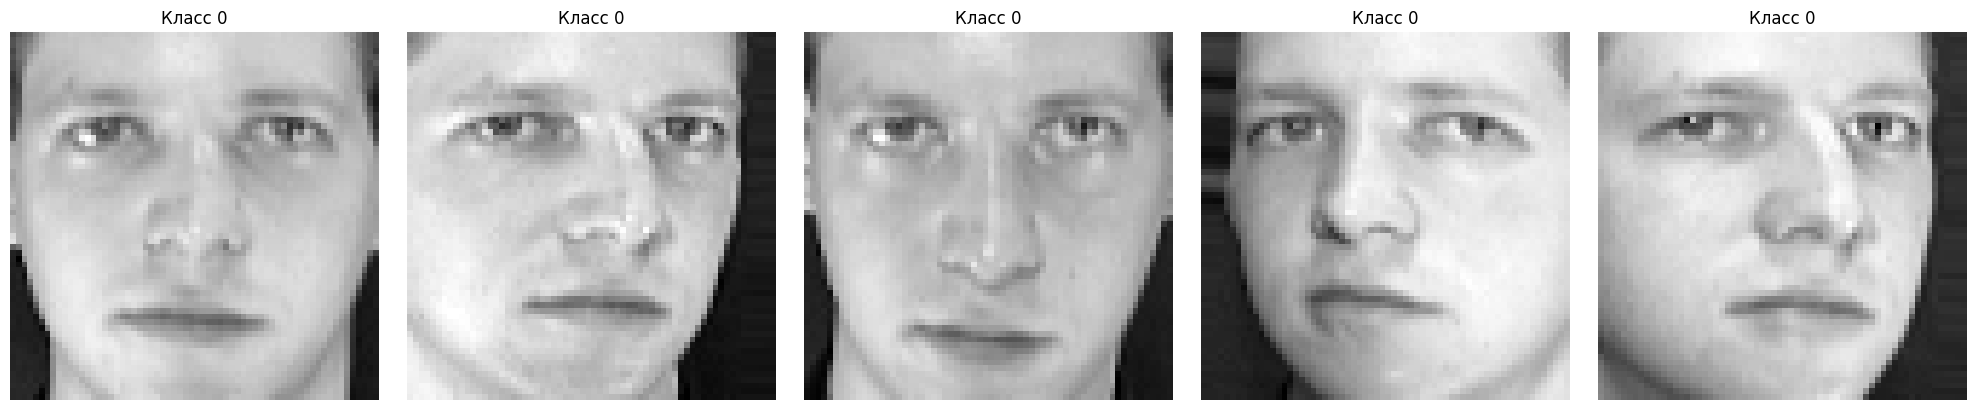

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


lr: accuracy=0.9800
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
      

,model,accuracy
0,lr,0.98
4,voting_soft,0.96
2,knn,0.93
3,nb,0.92
1,tree,0.31


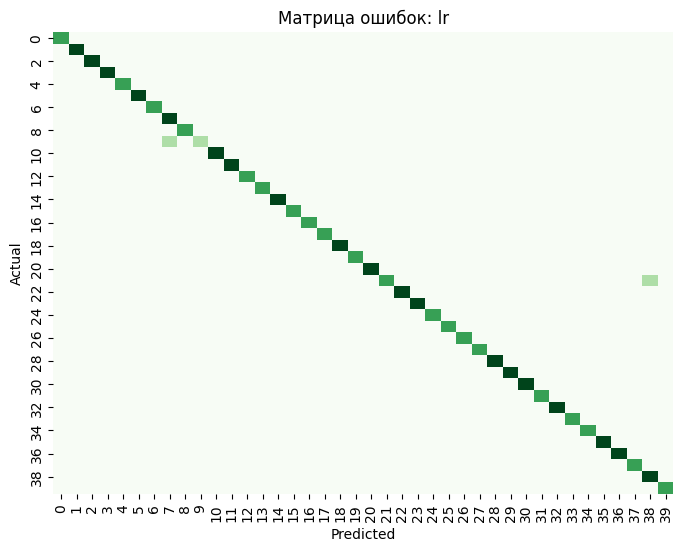

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

X = images.reshape(len(images), -1)
y = labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

base_estimators = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))),
    ("tree", DecisionTreeClassifier(max_depth=12, random_state=42)),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))),
    ("nb", GaussianNB()),
]

models_to_compare = {name: estimator for name, estimator in base_estimators}
models_to_compare["voting_soft"] = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1,
)

voting_results = []
for name, model in models_to_compare.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    voting_results.append({"model": name, "accuracy": acc})
    print(f"\n{name}: accuracy={acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

voting_results_df = pd.DataFrame(voting_results).sort_values("accuracy", ascending=False)
display(voting_results_df)

best_vote_name = voting_results_df.iloc[0]["model"]
cm = confusion_matrix(y_test, models_to_compare[best_vote_name].predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="Greens", cbar=False)
plt.title(f"Матрица ошибок: {best_vote_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

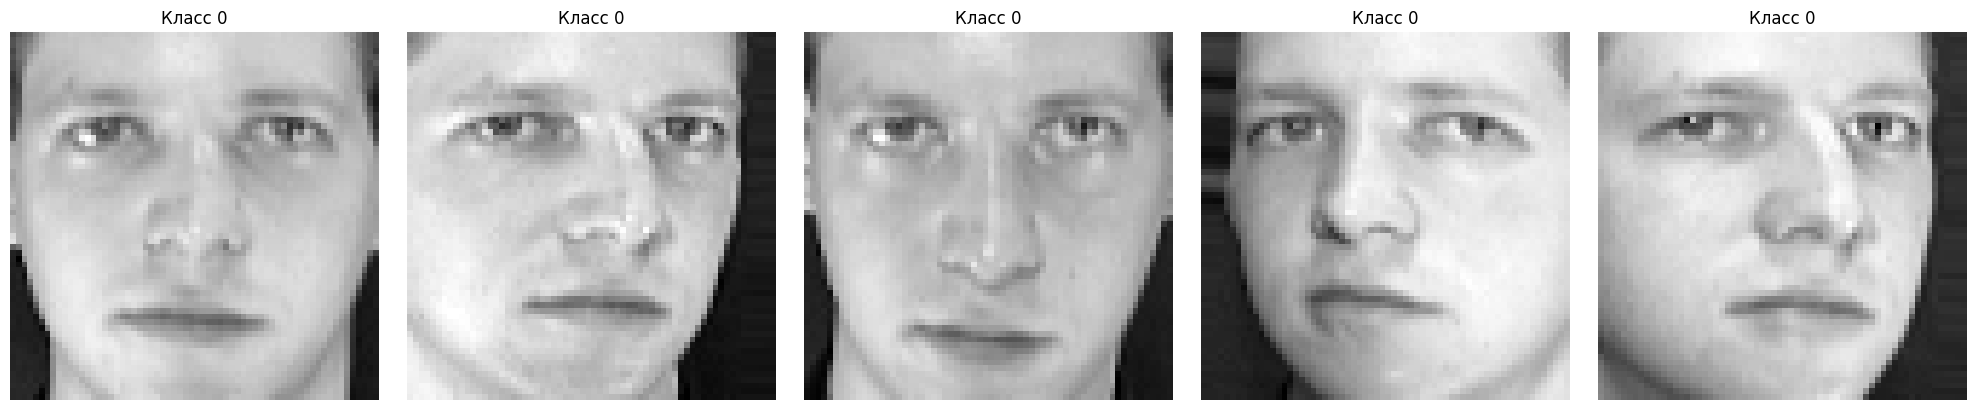

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

StackingClassifier accuracy: 0.9800
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00  

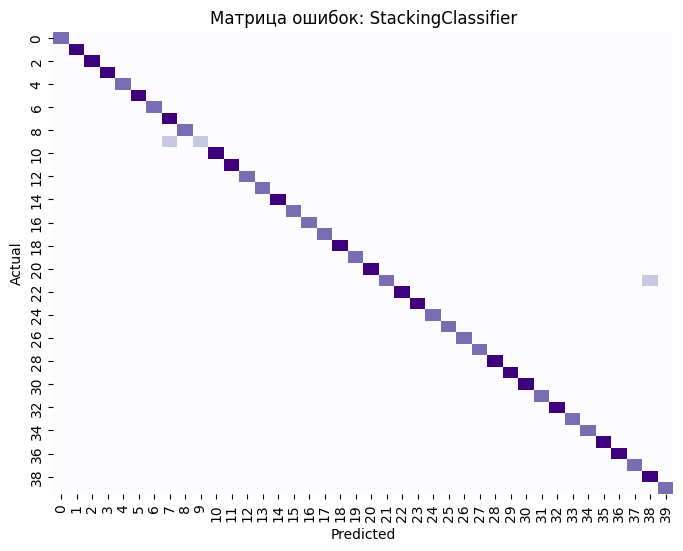

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier

X = images.reshape(len(images), -1)
y = labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

stack_estimators = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))),
    ("tree", DecisionTreeClassifier(max_depth=12, random_state=42)),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))),
    ("nb", GaussianNB()),
]

stacking = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    stack_method="predict_proba",
    cv=3,
    n_jobs=-1,
)

stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"StackingClassifier accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="Purples", cbar=False)
plt.title("Матрица ошибок: StackingClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
